In [1]:
import uvicorn
import threading
import pickle
from fastapi import FastAPI
from pydantic import BaseModel
from pyngrok import ngrok
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import joblib


# Showing the resulting Dataset

In [2]:
df_cleaned_clustered_airline= pd.read_csv('airline_UMAP_dbscan.csv')

In [3]:
df_cleaned_clustered_airline.info()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Balance            3999 non-null   float64
 1   Qual_miles         3999 non-null   float64
 2   cc1_miles          3999 non-null   float64
 3   cc2_miles          3999 non-null   float64
 4   cc3_miles          3999 non-null   float64
 5   Bonus_miles        3999 non-null   float64
 6   Bonus_trans        3999 non-null   float64
 7   Flight_miles_12mo  3999 non-null   float64
 8   Flight_trans_12    3999 non-null   float64
 9   Days_since_enroll  3999 non-null   float64
 10  Clusters           3999 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.8 KB


In [5]:
np.unique(df_cleaned_clustered_airline['Clusters'])

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [ ]:
colors = {
    '-1': '#1f77b4',
    '0': '#aec7e8',
    '1': '#ff7f0e',
    '2': '#ffbb78',
    '3': '#2ca02c',
    '4': '#98df8a',
    '5': '#d62728',
    '6': '#ff9896',
    '7': '#9467bd',
    '8': '#c5b0d5',
    '9': '#8c564b',
    '10': '#c49c94',
    '11': '#e377c2',
    '12': '#f7b6d2',
    '13': '#7f7f7f',
    '14': '#c7c7c7'
 }

# Plotting valuable info per Cluster

In [4]:
df_cleaned_clustered_airline['Clusters'].value_counts()

Clusters
 0     1082
 3     1074
 4      580
 1      533
 13     149
 6       82
 2       75
 9       75
 8       67
 10      61
 14      59
 5       43
 7       41
 11      31
 12      30
-1       17
Name: count, dtype: int64

In [6]:
df_cleaned_clustered_airline.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Clusters'],
      dtype='str')

C:\Users\seboc\AppData\Local\Temp\ipykernel_14880\672958474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned_clustered_airline, x='Clusters', y=feat, ax=axes[i],
C:\Users\seboc\AppData\Local\Temp\ipykernel_14880\672958474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned_clustered_airline, x='Clusters', y=feat, ax=axes[i],
C:\Users\seboc\AppData\Local\Temp\ipykernel_14880\672958474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned_clustered_airline, x='Clusters', y=feat, ax=axes[i],
C:\U

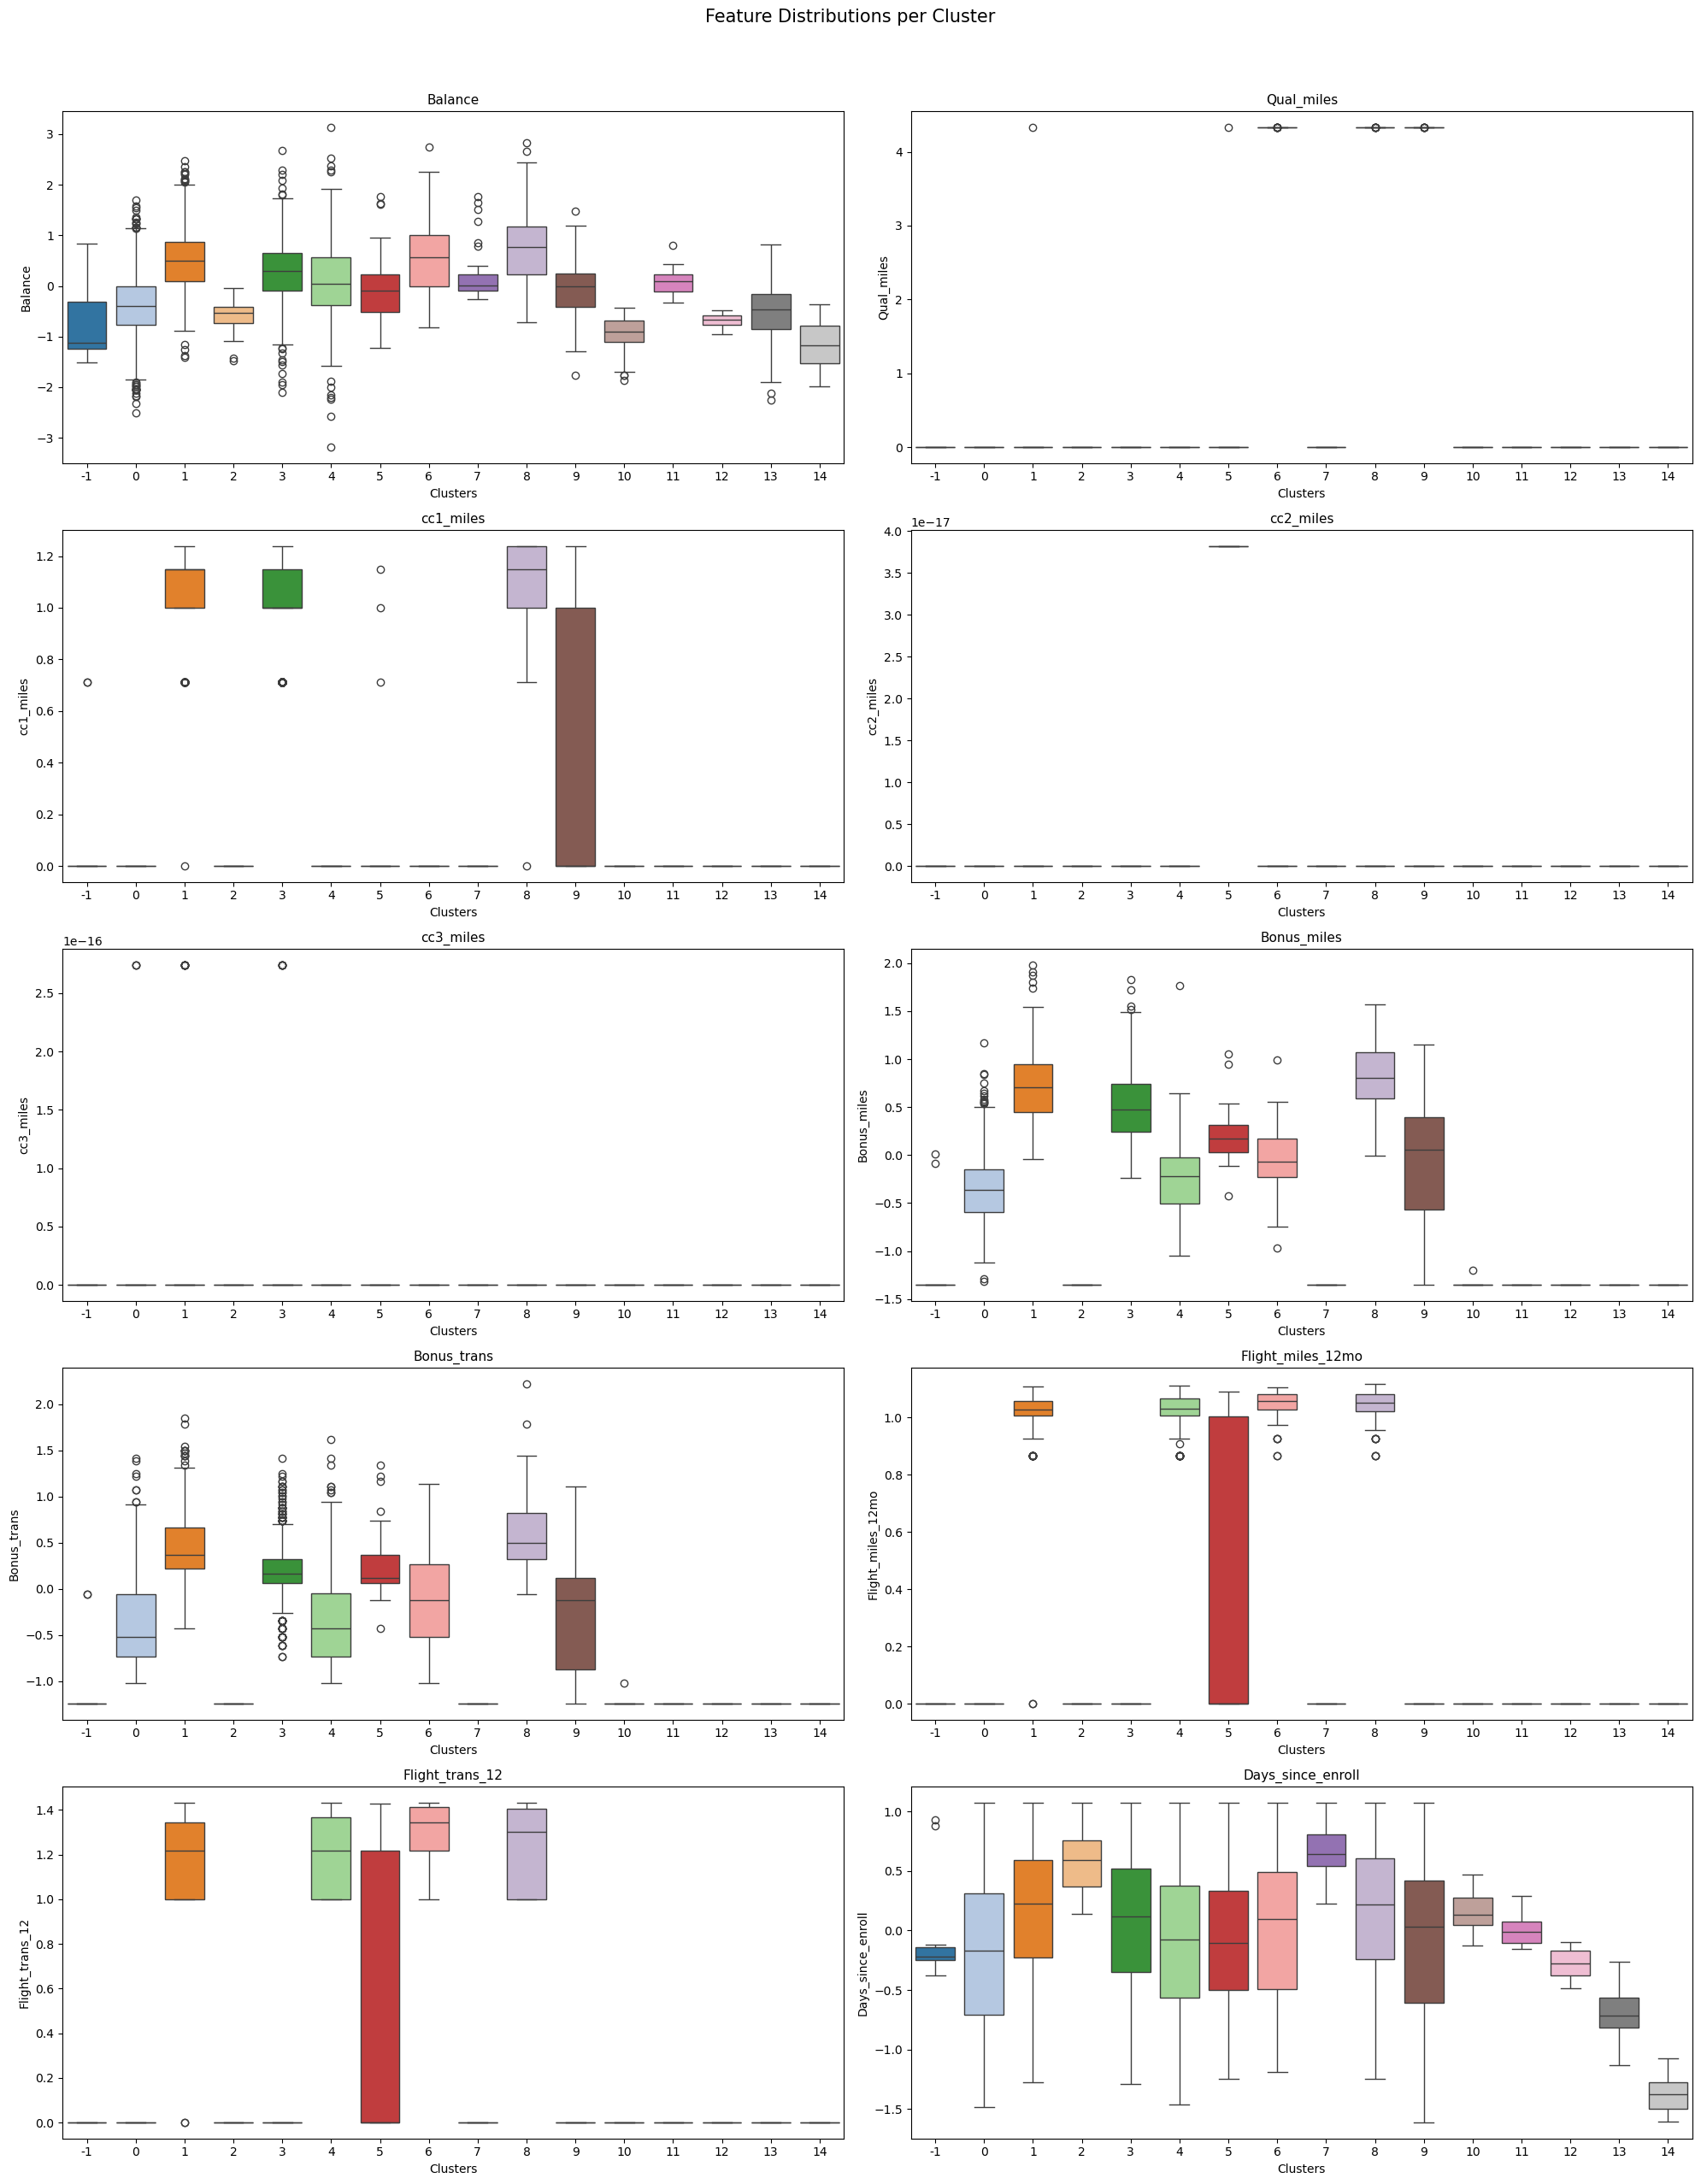

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes = axes.flatten()

for i, feat in enumerate(df_cleaned_clustered_airline.columns):
    if feat != 'Clusters':
        sns.boxplot(data=df_cleaned_clustered_airline, x='Clusters', y=feat, ax=axes[i],
                palette=colors)
        axes[i].set_title(feat, fontsize=11)

plt.suptitle('Feature Distributions per Cluster', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
df_cleaned_clustered_airline.groupby(by='Clusters').describe().to_csv('describe_groups.csv')

# Cluster Naming Analysis — Airline Loyalty Program

## 1. Understanding the Data

The features describe airline loyalty program behavior:

| Feature | What it captures |
|---|---|
| `Balance` | Accumulated miles balance |
| `Qual_miles` | Qualifying miles earned (elite status) |
| `cc1_miles` | Miles earned via credit card 1 |
| `cc2_miles` / `cc3_miles` | Miles earned via credit cards 2 and 3 *(near-zero across all clusters — excluded from analysis)* |
| `Bonus_miles` | Promotional / bonus miles earned |
| `Bonus_trans` | Number of bonus transactions |
| `Flight_miles_12mo` | Flight miles in the last 12 months |
| `Flight_trans_12` | Flight transactions in the last 12 months |
| `Days_since_enroll` | Tenure in the program |

Since the data is standardized (z-scores), values represent deviations from the overall mean: **positive = above average**, **negative = below average**.


## 2. Identifying Macro-Patterns

From the signal matrix, five macro-patterns emerge:

### Pattern A — High-Value Multi-Channel Engaged (Clusters 1, 8)
These members are active across **all channels**: they fly, use credit cards, earn bonus miles, and carry high balances. Cluster 8 additionally has high qualifying miles — they are the **elite tier**.

### Pattern B — Flyers Without Credit Card Earning (Clusters 4, 6)
Active flyers (high flight miles and transactions) but **no credit card miles**. Cluster 6 stands out with very high qualifying miles — these are **status-focused flyers** who earn through flights alone.

### Pattern C — Credit Card Earners, Non-Flyers (Clusters 3, 9)
They earn miles through credit cards (cc1) and may accumulate bonuses, but **don't actually fly**. Cluster 9 adds high qualifying miles, suggesting an alternative qualification path.

### Pattern D — Low-Engagement / Dormant (Clusters 2, 7, 10, 11, 12, 13, 14)
No flights, no credit card earning, and very low bonus activity. These differ mainly by **balance level** and **tenure**:
- High tenure + some balance → long-time dormant members
- Low tenure + very low balance → recently joined but never engaged
- Negative balance with medium tenure → lapsing members

### Pattern E — Baseline Low-Activity (Clusters 0, -1, 5)
Cluster 0 is the **largest group** (1,082 members) with slightly below-average everything — the broad "average low-activity" base. Cluster 5 shows moderate engagement across all channels (a **transitional** group). Cluster -1 is the **noise/outlier** cluster (DBSCAN artifact).

---

## 3. Naming Each Cluster — Rationale

### Cluster -1 (n=17) → `"Outliers / Noise"`
Only 17 members. Likely flagged by DBSCAN as noise. Low balance, very low bonus activity, some minor cc1 usage. Not a meaningful behavioral segment.

### Cluster 0 (n=1,082) → `"Low-Activity Base Members"`
The largest cluster. Below-average balance, slightly low bonus miles, zero flights, zero credit card earning. These are enrolled members with **minimal program engagement**.

### Cluster 1 (n=533) → `"High-Value Multi-Channel Loyalists"`
High across the board: flies frequently, earns through cc1, collects bonus miles, and maintains a high balance. The **most valuable non-elite segment** — they engage through every available channel.

### Cluster 2 (n=75) → `"Long-Tenured Dormant Members"`
Long-time members (high tenure) with low balance and **zero activity** across all earning channels. Very low bonus engagement. They joined long ago but have gone **completely dormant**.

### Cluster 3 (n=1,074) → `"Credit Card Earners — Non-Flyers"`
The second-largest cluster. They earn miles through cc1 and collect moderate bonuses, but **never fly**. Moderate balance. They are **ground-level loyalists** who participate via spending, not travel.

### Cluster 4 (n=580) → `"Flight-Only Travelers"`
Active flyers (high flight miles and transactions) but earn **no miles through credit cards or bonuses**. Average balance. They use the airline but **don't engage with partner earning programs**.

### Cluster 5 (n=43) → `"Moderate All-Rounders"`
Small group with moderate engagement across every channel — some flights, some cc1, some bonus miles, some qualifying miles. A **balanced but not heavy** usage pattern. Possibly transitioning toward higher engagement.

### Cluster 6 (n=82) → `"Elite Status Flyers"`
Very high qualifying miles (4.33σ!) combined with frequent flights and high balance, but **no credit card earning**. These are **status-focused frequent flyers** who earn exclusively through flying.

### Cluster 7 (n=41) → `"Long-Tenured Inactive — Moderate Balance"`
Similar to Cluster 2 (dormant, high tenure) but with a **slightly positive balance**. Zero activity everywhere. These are legacy members who may have earned miles long ago but are now **fully inactive**.

### Cluster 8 (n=67) → `"Premium Elite — Top-Tier Loyalists"`
The **highest engagement cluster**: top qualifying miles, top balance, high cc1 earning, high flights, and high bonus miles. These are the **best customers** — elite-status, multi-channel, heavy spenders.

### Cluster 9 (n=75) → `"Qualifying-Miles Earners — Low Flight Activity"`
High qualifying miles and some cc1 usage, but **no recent flights** and neutral bonus activity. They may have earned qualifying miles through **partner programs or past travel** but aren't currently active flyers.

### Cluster 10 (n=61) → `"Very Low Balance — Dormant"`
Very low balance (−0.96σ), zero activity, very low bonus. Slightly above-average tenure. These members have **depleted balances and stopped engaging** — possibly churned.

### Cluster 11 (n=31) → `"Neutral Balance — Fully Inactive"`
Near-zero balance, average tenure, and **zero engagement** across every channel. The most "blank" cluster — enrolled but showing **no behavioral signal** at all.

### Cluster 12 (n=30) → `"Low Balance — Recently Inactive"`
Below-average balance, slightly below-average tenure, zero activity. Similar to the dormant clusters but with a **shorter enrollment period** — they disengaged relatively early.

### Cluster 13 (n=149) → `"Low Balance — Lapsing Members"`
Below-average balance and **below-average tenure**. Zero activity everywhere. A sizable group of members who joined in the mid-term past but are **trending toward full churn**.

### Cluster 14 (n=59) → `"Very Low Balance — New Churned Members"`
The **lowest balance** (−1.17σ) and **lowest tenure** (−1.38σ) among dormant clusters. These are the **most recently enrolled members who never engaged** — immediate churn after sign-up.


In [2]:
cluster_names = {
    '-1': "Outliers / Noise",
     '0': "Low-Activity Base Members",
     '1': "High-Value Multi-Channel Loyalists",
     '2': "Long-Tenured Dormant Members",
     '3': "Credit Card Earners — Non-Flyers",
     '4': "Flight-Only Travelers",
     '5': "Moderate All-Rounders",
     '6': "Elite Status Flyers",
     '7': "Long-Tenured Inactive — Moderate Balance",
     '8': "Premium Elite — Top-Tier Loyalists",
     '9': "Qualifying-Miles Earners — Low Flight Activity",
    '10': "Very Low Balance — Dormant",
    '11': "Neutral Balance — Fully Inactive",
    '12': "Low Balance — Recently Inactive",
    '13': "Low Balance — Lapsing Members",
    '14': "Very Low Balance — New Churned Members",
}

# Implementing FastAPI

In [10]:
preprocessor = joblib.load("./pkl/preprocessor.pkl")
scaler = joblib.load("./pkl/scaler.pkl")
umap = joblib.load("./pkl/umap.pkl")
dbscan = joblib.load("./pkl/dbscan_UMAP_model.pkl")
training_embeddings = joblib.load("./pkl/umap_embeddings.pkl")  # UMAP-transformed training data


c:\Users\seboc\anaconda3\envs\umap_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\seboc\anaconda3\envs\umap_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\seboc\anaconda3\envs\umap_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using 

In [4]:
core_mask = dbscan.core_sample_indices_
core_samples = training_embeddings[core_mask]
core_labels = dbscan.labels_[core_mask]
nn_model = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(core_samples)

In [5]:
class CustomerData(BaseModel):
    Balance: float
    Qual_miles: float
    cc1_miles: float
    cc2_miles: float
    cc3_miles: float
    Bonus_miles: float
    Bonus_trans: float
    Flight_miles_12mo: float
    Flight_trans_12: float
    Days_since_enroll: float

In [ ]:
# Initialize FastAPI application
app = FastAPI()

@app.get("/")
def home():
    return {"message": "Airline Customer Clustering API is running!"}


def get_customer_clustering(cluster: str):
    cluster_names = {
        '-1': "Outliers / Noise",
         '0': "Low-Activity Base Members",
         '1': "High-Value Multi-Channel Loyalists",
         '2': "Long-Tenured Dormant Members",
         '3': "Credit Card Earners — Non-Flyers",
         '4': "Flight-Only Travelers",
         '5': "Moderate All-Rounders",
         '6': "Elite Status Flyers",
         '7': "Long-Tenured Inactive — Moderate Balance",
         '8': "Premium Elite — Top-Tier Loyalists",
         '9': "Qualifying-Miles Earners — Low Flight Activity",
        '10': "Very Low Balance — Dormant",
        '11': "Neutral Balance — Fully Inactive",
        '12': "Low Balance — Recently Inactive",
        '13': "Low Balance — Lapsing Members",
        '14': "Very Low Balance — New Churned Members",
    }
    return cluster_names.get(cluster, "Unknown Cluster")


@app.post("/predict/")
def predict_cluster(data: CustomerData):
    input_data = np.array([[data.Balance, data.Qual_miles, data.cc1_miles,
                            data.cc2_miles, data.cc3_miles, data.Bonus_miles,
                            data.Bonus_trans, data.Flight_miles_12mo,
                            data.Flight_trans_12, data.Days_since_enroll]])

    columns = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
               'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
               'Days_since_enroll']

    df_input = pd.DataFrame(input_data, columns=columns)
    first_transformation = preprocessor.transform(df_input)
    df_first_transformation = pd.DataFrame(first_transformation, columns=columns)
    input_scaled = scaler.transform(df_first_transformation)
    input_embedded = umap.transform(input_scaled)

    # Assign cluster via nearest DBSCAN core sample
    dist, idx = nn_model.kneighbors(input_embedded)
    if dist[0][0] <= dbscan.eps:
        cluster = int(core_labels[idx[0][0]])
    else:
        cluster = -1  # Too far from any core point → noise

    result = get_customer_clustering(str(cluster))

    return {"Cluster": cluster, "Customer_classification": result}


# --- Expose the API with ngrok ---
port = 8000
!ngrok config add-authtoken 2tvNOdmHFqJbP9UDsXINjpX7LB7_5jDgUa24mpxAhcyFcwVFH
public_url = ngrok.connect(port).public_url
print(f"🔗 Public API URL: {public_url}")

# Start the FastAPI server in a new thread
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run).start()

Authtoken saved to configuration file: C:\Users\seboc\AppData\Local/ngrok/ngrok.yml
🔗 Public API URL: https://84f1-2800-e2-1f80-4d9-246d-7c30-372f-3d8b.ngrok-free.app


INFO:     Started server process [30860]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2800:e2:1f80:4d9:246d:7c30:372f:3d8b:0 - "POST /predict/ HTTP/1.1" 200 OK
INFO:     2800:e2:1f80:4d9:246d:7c30:372f:3d8b:0 - "POST /predict/ HTTP/1.1" 200 OK
INFO:     2800:e2:1f80:4d9:246d:7c30:372f:3d8b:0 - "POST /predict/ HTTP/1.1" 200 OK


In [ ]:
import requests

# Your ngrok URL (replace with the one printed when you start the API)
API_URL = public_url + "/predict/"

test_customers = [
    {"Balance": 22412, "Qual_miles": 0, "cc1_miles": 3, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 11654, "Bonus_trans": 12, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 4460},
    {"Balance": 119735, "Qual_miles": 0, "cc1_miles": 3, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 22432, "Bonus_trans": 17, "Flight_miles_12mo": 1000, "Flight_trans_12": 2, "Days_since_enroll": 1996},
    {"Balance": 38918, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 6505, "Bonus_trans": 29, "Flight_miles_12mo": 618, "Flight_trans_12": 2, "Days_since_enroll": 4442},
    {"Balance": 37212, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 0, "Bonus_trans": 0, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 2455},
    {"Balance": 22678, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 2125, "Bonus_trans": 7, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 4068},
    {"Balance": 16875, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 500, "Bonus_trans": 1, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 1838},
    {"Balance": 34584, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 6962, "Bonus_trans": 21, "Flight_miles_12mo": 1500, "Flight_trans_12": 7, "Days_since_enroll": 5202},
    {"Balance": 26740, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 619, "Bonus_trans": 7, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 6213},
    {"Balance": 15098, "Qual_miles": 0, "cc1_miles": 4, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 32917, "Bonus_trans": 26, "Flight_miles_12mo": 550, "Flight_trans_12": 3, "Days_since_enroll": 6737},
    {"Balance": 38465, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 10550, "Bonus_trans": 3, "Flight_miles_12mo": 550, "Flight_trans_12": 2, "Days_since_enroll": 1580},
    {"Balance": 9800, "Qual_miles": 589, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 10348, "Bonus_trans": 34, "Flight_miles_12mo": 3000, "Flight_trans_12": 25, "Days_since_enroll": 6651},
    {"Balance": 58538, "Qual_miles": 1739, "cc1_miles": 4, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 48670, "Bonus_trans": 19, "Flight_miles_12mo": 500, "Flight_trans_12": 2, "Days_since_enroll": 4352},
    {"Balance": 54039, "Qual_miles": 0, "cc1_miles": 1, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 5250, "Bonus_trans": 22, "Flight_miles_12mo": 1250, "Flight_trans_12": 10, "Days_since_enroll": 1709},
    {"Balance": 123842, "Qual_miles": 0, "cc1_miles": 3, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 24295, "Bonus_trans": 14, "Flight_miles_12mo": 0, "Flight_trans_12": 0, "Days_since_enroll": 2500},
    {"Balance": 45501, "Qual_miles": 0, "cc1_miles": 4, "cc2_miles": 1, "cc3_miles": 1, "Bonus_miles": 49656, "Bonus_trans": 17, "Flight_miles_12mo": 316, "Flight_trans_12": 1, "Days_since_enroll": 6375},
]


Status: 200 | Response: {"Cluster":3,"Customer_classification":"Credit Card Earners — Non-Flyers"}


In [9]:
response = requests.post(API_URL, json=test_customers[3])
print(f"Status: {response.status_code} | Response: {response.text[:200]}")

Status: 200 | Response: {"Cluster":13,"Customer_classification":"Low Balance — Lapsing Members"}


## Consideration

run this commands in your PowerShell console it you have problems re-executing FastAPI

- netstat -ano
- TCP    0.0.0.0:8080    0.0.0.0:0    LISTENING    12345
- tasklist | findstr 12345
- taskkill /PID 12345 /F
- tasklist | findstr ngrok
- taskkill /IM ngrok.exe /F